# ABOUT DATASET
Healthcare is one of the most critical sectors in the economy, and understanding the factors that drive insurance costs is essential for both insurers and patients.

This dataset provides a granular look at the personal health data of 1,338 individuals in the United States. It reveals how factors like age, BMI, smoking habits, and family size influence the final medical bills charged by health insurance companies.

It is a clean, perfect-for-beginners dataset to practice Regression Analysis (predicting a number) and Data Visualiza

🎯 Who can use this dataset?
This dataset is designed for a wide range of users:

👶 Beginners in Data Science: Perfect for your first "Linear Regression" project. The data is clean and requires minimal preprocessing.
🤖 ML Practitioners: Ideal for practicing feature engineering (e.g., converting "Region" to numbers) and comparing models like Random Forest vs. XGBoost.
📊 Data Analysts: Great for exploring questions like "Do smokers really pay more?" or "How does BMI affect costs in different regions?".
🎓 Students & Educators: A classic dataset for teaching statistics, correlation, and hypothesis te

📂 Dataset Content
File Name: medical-charges.csv
Size: ~1,300 Records
Columns: 7 Key Attributes
Data Type: Categorical (Sex, Smoker, Region) & Numerical (Age, BMI, Char

💡 Inspiration: Projects you can build
💰 Insurance Cost Predictor: Build a Machine Learning model (Linear Regression, Gradient Boosting) to predict the exact insurance cost for a new person.
🚬 The "Smoker's Penalty" Analysis: Quantify exactly how much smoking adds to the medical bill on average.
⚖️ Regional Disparities: Visualize the data to see if people in the "Southeast" have higher BMIs or charges compared to the "Northwest".
📉 BMI vs. Charges: Analyze the correlation. Is there a "tipping point" in BMI where charges skyrocket?ges)sting.tion.

# PROBLEM STATEMENT
- **Berapa rata-rata biaya medis untuk perokok vs non-perokok?**
- **Seberapa besar pengaruh BMI terhadap biaya medis? Apakah ada titik kritis (tipping point)?**
- **Apakah usia berkontribusi signifikan terhadap kenaikan biaya asuransi?**
- **Apakah ada interaksi antara usia dan status merokok dalam menentukan biaya?**
- **Bisakah kita membangun model prediksi biaya medis untuk pelanggan baru?**
- **Fitur mana yang paling berkontribusi dalam prediksi biaya? (feature importance)**

# 1. IMPORT PACKAGE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

C:\Users\USER\AppData\Local\Temp\ipykernel_4296\2767306022.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install data-profiling via `pip install data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# 2. LOAD A DATASET

In [2]:
df = pd.read_csv('../medical-charges.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# 3. PRE-EDA / ASSESSING DATA

## 3.1 Data Summary

In [3]:
# 2️⃣ Buat laporan profiling
profile = ProfileReport(
    df,
    title="Medical Insurance Cost Profiling Report",
    explorative=True
)

# 3️⃣ Tampilkan laporan di notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 35.02it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 3.2 Descriptive Statistics

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3.3 Outlier Detection

### Boxplot

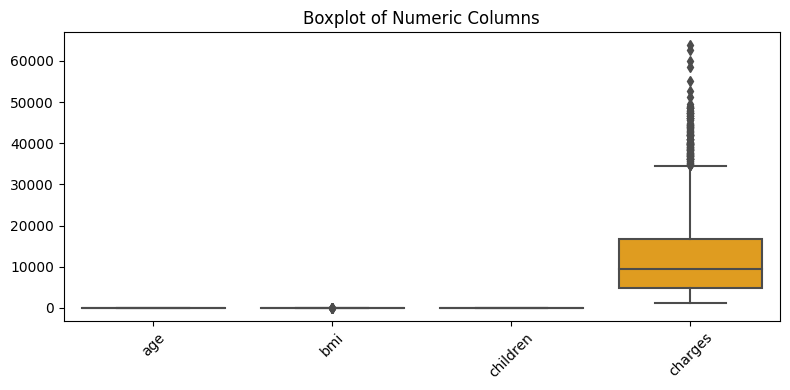

In [6]:
%matplotlib inline

# Pilih kolom numerik
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Buat boxplot semua kolom numerik dalam satu chart
plt.figure(figsize=(8,4))
sns.boxplot(data=df[numeric_cols], color="orange")
plt.title("Boxplot of Numeric Columns")
plt.xticks(rotation=45)  # putar label agar tidak bertumpuk
plt.tight_layout()
plt.show()

# 4. DATA CLEANING

## 4.1 Handle Duplicate

In [7]:
# Menampilkan semua baris yang terdeteksi duplikat
duplicates = df[df.duplicated(keep=False)]

print("Jumlah baris duplikat:", len(duplicates))
duplicates.head()

Jumlah baris duplikat: 2


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
# Hapus duplikat, simpan hanya baris pertama dari setiap duplikat
df_clean = df.drop_duplicates(keep='first')

# Jika ingin simpan hanya baris terakhir dari setiap duplikat
# df_clean = df.drop_duplicates(keep='last')

print("Jumlah baris sebelum:", len(df))
print("Jumlah baris sesudah:", len(df_clean))
df_clean.head()

Jumlah baris sebelum: 1338
Jumlah baris sesudah: 1337


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4.2 Handle Outlier

### 4.2.1 Comparing Machine Learning Models

In [9]:
from pycaret.regression import setup, compare_models

# Setup awal tanpa remove outlier
s = setup(
    data=df,
    target='charges',
    session_id=123,
    verbose=False   # gunakan ini untuk meminimalkan output
)

# Bandingkan semua model ML
best_model = compare_models()
print(best_model)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2701.9927,23548981.3626,4832.9682,0.8320,0.4447,0.3137,0.1510
rf,Random Forest Regressor,2771.4583,25416502.3827,5028.6343,0.8172,0.4690,0.3303,0.3380
lightgbm,Light Gradient Boosting Machine,2992.1828,25521038.3331,5042.0978,0.8149,0.5378,0.3751,0.2880
et,Extra Trees Regressor,2833.3624,28427844.2412,5305.6516,0.7991,0.4877,0.3363,0.3560
ada,AdaBoost Regressor,4316.0568,29220505.6498,5398.4561,0.7903,0.6368,0.7394,0.1190
xgboost,Extreme Gradient Boosting,3443.6091,32824626.4000,5711.2140,0.7626,0.6224,0.4469,0.2190
br,Bayesian Ridge,4311.2349,38391950.0874,6176.8896,0.7306,0.5910,0.4447,0.1490
llar,Lasso Least Angle Regression,4303.7694,38386824.2786,6176.4846,0.7306,0.5952,0.4434,0.0820
lr,Linear Regression,4303.5559,38388058.4578,6176.5920,0.7306,0.5949,0.4433,2.4360
lar,Least Angle Regression,4303.5559,38388058.4578,6176.5920,0.7306,0.5949,0.4433,0.0810


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

GradientBoostingRegressor(random_state=123)


### Insight :
- **Gradient Boosting Regressor (GBR)**  
  - **R² = 0.832, RMSE ≈ 4833** → model terbaik, paling akurat.  
  - Error rata-rata (MAE) lebih rendah dibanding Random Forest dan LightGBM.  
  - Cocok untuk dataset dengan pola non-linear dan interaksi antar variabel.  

- **Random Forest Regressor (R² = 0.817, RMSE ≈ 5029)**  
  - Hampir setara dengan GBR, tapi sedikit lebih lemah.  
  - Lebih tahan terhadap outlier dibanding model linear.  
  - Memberikan interpretasi lewat feature importance.  

- **LightGBM (R² = 0.815, RMSE ≈ 5042)**  
  - Performa mirip Random Forest, tapi lebih cepat (TT = 0.163 detik).  
  - Cocok untuk dataset besar karena efisiensi tinggi.  

- **Extra Trees & AdaBoost**  
  - R² sekitar 0.79–0.80, masih cukup baik tapi lebih variatif.  
  - AdaBoost lebih sensitif terhadap outlier.  

- **XGBoost (R² = 0.763, RMSE ≈ 5711)**  
  - Biasanya kuat, tapi di dataset ini kalah dari GBR dan RF.  
  - Bisa jadi karena parameter default belum optimal.  

- **Linear Models (Linear Regression, Ridge, Lasso, Bayesian Ridge)**  
  - R² sekitar 0.73, RMSE ≈ 6177.  
  - Masih berguna sebagai baseline interpretatif, tapi kalah akurasi dari tree-based.  

- **Model lain (Huber, Decision Tree, KNN, Elastic Net, Dummy)**  
  - R² < 0.65, bahkan negatif untuk Dummy.  
  - Tidak cocok untuk dataset ini.  

---

**Insight praktis**
1. **Best choice untuk prediksi akurat** → **Gradient Boosting Regressor**.  
2. **Alternatif cepat & scalable** → **LightGBM**.  
3. **Baseline interpretatif** → **Linear Regression / Ridge** (meski akurasi lebih rendah).  
4. **Handling outlier** → Tree-based models (GBR, RF, LightGBM) lebih tahan terhadap outlier, sehingga tidak perlu filtering agresif. Linear models butuh preprocessing (winsorizing, log transform).  

---

**Rekomendasi**
- Gunakan **GBR** sebagai model utama untuk prediksi biaya medis.  
- Bandingkan dengan **Random Forest/LightGBM** untuk validasi performa.  
- Simpan **Linear Regression** sebagai baseline interpretatif (untuk menjelaskan faktor risiko seperti smoker, BMI, usia).  
- Jika ingin meningkatkan XGBoost, lakukan **hyperparameter tuning** (learning rate, max_depth, n_estimators).  

### 4.2.2 Evaluating Outlier Detection Algorithms

### Insight :

Untuk model **Gradient Boosting Regressor (GBR), Random Forest (RF), dan LightGBM**, sebenarnya mereka termasuk **tree-based ensemble models** yang relatif **robust terhadap outlier**. Artinya, outlier tidak terlalu merusak performa karena algoritma pohon membagi data berdasarkan threshold, bukan garis regresi atau jarak.  

Namun, tetap ada alasan untuk melakukan *outlier handling* agar hasil lebih stabil dan interpretasi lebih baik. Berikut algoritma/metode yang cocok:  

---

**Algoritma/Metode Outlier Handling yang relevan**
1. **Isolation Forest (IForest)**  
   - Cocok untuk dataset besar, cepat, dan sering dipakai untuk deteksi outlier sebelum modeling.  
   - Bisa dipakai untuk *flagging* data ekstrem, lalu diputuskan apakah dihapus atau ditransformasi.  

2. **Local Outlier Factor (LOF)**  
   - Bagus untuk mendeteksi outlier berbasis *density lokal*.  
   - Cocok jika distribusi data tidak homogen (misalnya BMI vs charges).  

3. **KNN Outlier Detection**  
   - Berbasis jarak ke tetangga terdekat.  
   - Cocok untuk dataset dengan pola cluster yang jelas.  

4. **Metode Statistik Klasik (IQR, Winsorizing, Log Transform)**  
   - **IQR filtering** → sederhana, cepat, cocok untuk preprocessing.  
   - **Winsorizing** → menjaga data tetap ada, hanya membatasi ekstrem.  
   - **Log transform** → menstabilkan distribusi skewed (misalnya charges).  

---

**Insight khusus untuk GBR, RF, LightGBM**
- **Tidak wajib remove outlier** → karena model pohon relatif tahan.  
- **Tetap disarankan transformasi log** pada variabel target (charges) → agar distribusi lebih normal dan split pohon lebih stabil.  
- **Jika dataset kecil** → gunakan IQR filtering atau Winsorizing untuk menghindari bias dari data ekstrem.  
- **Jika dataset besar** → cukup flagging dengan Isolation Forest/LOF, lalu analisis apakah outlier valid atau noise.  

---

📌 **Kesimpulan**:  
- Untuk GBR, RF, LightGBM → **Isolation Forest atau LOF** cocok sebagai algoritma deteksi outlier.  
- Untuk preprocessing tambahan → gunakan **IQR filtering, Winsorizing, atau log transform**.  
- Karena tree-based relatif robust, fokus utama bukan menghapus outlier, tapi memastipan masing-masing paling cocok dipakai?n masing-masing paling cocok dipakai?

In [10]:
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.lof import LOF

In [11]:
X = df[['age','bmi','charges']]

# 2️⃣ Inisialisasi model
models = {
    'KNN': KNN(),
    'Isolation Forest': IForest(),
    'LOF': LOF()
}

# 3️⃣ Fit dan prediksi
results = {}
for name, model in models.items():
    model.fit(X)
    y_pred = model.predict(X)   # 0 = normal, 1 = outlier
    results[name] = sum(y_pred)

# 4️⃣ Ringkasan hasil
print("Jumlah outlier terdeteksi:")
for name, count in results.items():
    print(f"{name}: {count}")

Jumlah outlier terdeteksi:
KNN: 86
Isolation Forest: 134
LOF: 89


### 4.2.3 Handle Outlier

In [12]:
# Import library PyCaret
from pycaret.regression import setup, compare_models
from scipy.stats.mstats import winsorize

# --- Dataset Original ---
df_original = df.copy()

#### 4.2.3.1 Setup tanpa remove outlier

In [13]:
# --- 1. Setup tanpa remove outlier ---
s_original = setup(
    data=df_original,
    target='charges',
    session_id=123,
    verbose=False
)
best_original = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2701.9927,23548981.3626,4832.9682,0.8320,0.4447,0.3137,0.1580
rf,Random Forest Regressor,2771.4583,25416502.3827,5028.6343,0.8172,0.4690,0.3303,0.3420
lightgbm,Light Gradient Boosting Machine,2992.1828,25521038.3331,5042.0978,0.8149,0.5378,0.3751,0.2210
et,Extra Trees Regressor,2833.3624,28427844.2412,5305.6516,0.7991,0.4877,0.3363,0.2680
ada,AdaBoost Regressor,4316.0568,29220505.6498,5398.4561,0.7903,0.6368,0.7394,0.1200
xgboost,Extreme Gradient Boosting,3443.6091,32824626.4000,5711.2140,0.7626,0.6224,0.4469,0.1600
br,Bayesian Ridge,4311.2349,38391950.0874,6176.8896,0.7306,0.5910,0.4447,0.0780
llar,Lasso Least Angle Regression,4303.7694,38386824.2786,6176.4846,0.7306,0.5952,0.4434,0.0950
lr,Linear Regression,4303.5559,38388058.4578,6176.5920,0.7306,0.5949,0.4433,0.0930
lar,Least Angle Regression,4303.5559,38388058.4578,6176.5920,0.7306,0.5949,0.4433,0.0910


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

#### 4.2.3.2 Setup dengan IQR Filtering

In [14]:
# --- Dataset IQR Filtering ---
df_iqr = df.copy()
Q1 = df_iqr['charges'].quantile(0.25)
Q3 = df_iqr['charges'].quantile(0.75)
IQR = Q3 - Q1
df_iqr = df_iqr[(df_iqr['charges'] >= Q1 - 1.5*IQR) & (df_iqr['charges'] <= Q3 + 1.5*IQR)]

# --- 2. Setup dengan IQR Filtering ---
s_iqr = setup(
    data=df_iqr,
    target='charges',
    session_id=123,
    verbose=False
)
best_iqr = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,2557.3650,20641595.1841,4485.8637,0.6254,0.4337,0.3135,0.1760
rf,Random Forest Regressor,2678.0209,22179285.9089,4652.5490,0.5989,0.4622,0.3332,0.3180
ridge,Ridge Regression,2710.2586,22392701.9846,4681.5393,0.5962,0.4271,0.3191,0.0900
br,Bayesian Ridge,2709.4400,22392445.4808,4681.5727,0.5962,0.4269,0.3186,0.0930
lr,Linear Regression,2705.8124,22391834.9081,4681.8004,0.5961,0.4261,0.3160,0.0980
lasso,Lasso Regression,2705.8118,22390301.0703,4681.6002,0.5961,0.4262,0.3162,0.1030
llar,Lasso Least Angle Regression,2705.8124,22390301.5502,4681.6003,0.5961,0.4262,0.3162,0.0880
lar,Least Angle Regression,2706.9263,22417919.9894,4685.4540,0.5955,0.4262,0.3114,0.0990
lightgbm,Light Gradient Boosting Machine,2974.8799,23676042.4720,4818.3386,0.5686,0.5328,0.3809,0.2090
huber,Huber Regressor,2006.2255,24040959.5146,4840.9574,0.5678,0.4240,0.1506,0.1040


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

#### 4.2.3.3 Setup dengan Log Transform

In [15]:
# --- Dataset Log Transform ---
df_log = df.copy()
df_log['charges_log'] = np.log1p(df_log['charges'])

# --- 3. Setup dengan Log Transform ---
s_log = setup(
    data=df_log,
    target='charges_log',
    session_id=123,
    verbose=False
)
best_log = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.0029,0.0000,0.0055,1.0000,0.0005,0.0003,0.3660
gbr,Gradient Boosting Regressor,0.0060,0.0001,0.0085,0.9999,0.0009,0.0007,0.1870
knn,K Neighbors Regressor,0.0032,0.0001,0.0063,0.9999,0.0006,0.0004,0.1080
xgboost,Extreme Gradient Boosting,0.0067,0.0001,0.0101,0.9999,0.0010,0.0007,0.1630
et,Extra Trees Regressor,0.0036,0.0001,0.0080,0.9999,0.0007,0.0004,0.2750
dt,Decision Tree Regressor,0.0042,0.0001,0.0080,0.9999,0.0008,0.0005,0.1080
lightgbm,Light Gradient Boosting Machine,0.0094,0.0005,0.0211,0.9994,0.0023,0.0011,0.1990
ada,AdaBoost Regressor,0.0464,0.0038,0.0597,0.9955,0.0061,0.0052,0.1410
lar,Least Angle Regression,0.2151,0.0959,0.3091,0.8883,0.0305,0.0238,0.0940
ridge,Ridge Regression,0.2151,0.0959,0.3090,0.8883,0.0305,0.0238,0.0800


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

#### 4.2.3.4 Setup dengan Winsorizing

In [16]:
# --- Dataset Winsorizing ---
df_winsor = df.copy()
df_winsor['charges_winsor'] = winsorize(df_winsor['charges'], limits=[0.01, 0.01])

# --- 4. Setup dengan Winsorizing ---
s_winsor = setup(
    data=df_winsor,
    target='charges_winsor',
    session_id=123,
    verbose=False
)
best_winsor = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
knn,K Neighbors Regressor,35.1174,5190.5758,68.2333,1.0000,0.0041,0.0027,0.1060
rf,Random Forest Regressor,33.5945,4752.7255,66.9611,1.0000,0.0037,0.0025,0.3550
dt,Decision Tree Regressor,57.7476,17582.0579,124.9897,0.9999,0.0071,0.0041,0.0830
et,Extra Trees Regressor,53.6851,19309.0654,134.8032,0.9999,0.0058,0.0031,0.3260
gbr,Gradient Boosting Regressor,66.8870,9643.7403,97.6693,0.9999,0.0109,0.0074,0.1990
lightgbm,Light Gradient Boosting Machine,78.8151,27864.7860,156.7426,0.9998,0.0148,0.0073,0.2310
xgboost,Extreme Gradient Boosting,84.8208,25805.0852,155.1608,0.9998,0.0105,0.0072,0.1620
br,Bayesian Ridge,125.2663,308999.4960,402.9584,0.9978,0.0189,0.0115,0.0790
lar,Least Angle Regression,139.5619,309428.8267,417.8092,0.9978,0.0188,0.0111,0.0900
en,Elastic Net,126.9767,308581.1438,403.9416,0.9978,0.0162,0.0102,0.0890


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

In [17]:
# --- Cetak hasil ---
print("Model terbaik tanpa filtering:", best_original)
print("Model terbaik dengan IQR filtering:", best_iqr)
print("Model terbaik dengan log transform:", best_log)
print("Model terbaik dengan winsorizing:", best_winsor)

Model terbaik tanpa filtering: GradientBoostingRegressor(random_state=123)
Model terbaik dengan IQR filtering: GradientBoostingRegressor(random_state=123)
Model terbaik dengan log transform: RandomForestRegressor(n_jobs=-1, random_state=123)
Model terbaik dengan winsorizing: KNeighborsRegressor(n_jobs=-1)


 ### Insight :

- **Tanpa filtering** → *GradientBoostingRegressor* tetap unggul.  
- **Dengan IQR filtering** → *GradientBoostingRegressor* masih konsisten terbaik.  
- **Dengan log transform** → *RandomForestRegressor* muncul sebagai kandidat kuat.  
- **Dengan winsorizing** → *KNeighborsRegressor* jadi terbaik, tapi ini lebih karena data ekstrem ditekan.  

**Interpretasi**
1. **Gradient Boosting Regressor (GBR)** konsisten unggul di dua skenario (original & IQR). Ini menunjukkan model cukup robust terhadap outlier, dan filtering sederhana tidak banyak mengubah hasil.  
2. **Random Forest** naik performa setelah log transform → artinya distribusi target yang lebih stabil membantu pohon membuat split lebih baik.  
3. **KNN** hanya unggul di winsorizing → karena KNN sangat sensitif terhadap jarak, sehingga ketika outlier ditekan, performanya meningkat. Namun, ini bukan indikasi bahwa KNN lebih cocok secara umum.  

---

**Saran Langkah Selanjutnya**
1. **Fokus pada Gradient Boosting & Random Forest**  
   - Kedua model ini terbukti stabil dan kuat.  
   - Lanjutkan dengan **hyperparameter tuning** (misalnya `tune_model()` di PyCaret) untuk mengoptimalkan performa.  

2. **Gunakan Log Transform pada target (`charges`)**  
   - Karena Random Forest menunjukkan peningkatan signifikan, log transform bisa dijadikan default preprocessing.  
   - Ini juga membantu interpretasi distribusi lebih normal.  

3. **Winsorizing/IQR Filtering hanya sebagai eksperimen tambahan**  
   - Bisa dipakai untuk validasi robustness, tapi tidak perlu dijadikan pipeline utama.  
   - Tree-based models relatif tahan terhadap outlier, jadi tidak wajib remove.  

4. **Evaluasi dengan cross-validation & hold-out test set**  
   - Pastikan hasil tidak hanya bagus di training/validation PyCaret, tapi juga konsisten di data unseen.  

---

**Kesimpulan Praktis**
- **Pipeline utama:** Log transform target + Gradient Boosting / Random Forest.  
- **Next step:** Hyperparameter tuning + cross-validation.  
- **Eksperimen tambahan:** Winsorizing/IQR untuk validasi langsung lihat efeknya secara visual?ngsung lihat efeknya secara visual?

In [18]:
# Fungsi untuk mendeteksi outlier dengan IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

In [19]:
# Cari kolom numerik
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Deteksi outlier per kolom
outlier_summary = {}
for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_summary[col] = len(outliers)

print("Jumlah outlier per kolom:", outlier_summary)

Jumlah outlier per kolom: {'age': 0, 'bmi': 9, 'children': 0, 'charges': 139}


In [20]:
# Pilih hanya kolom dengan outlier signifikan (misalnya > 5% dari total data)
threshold = 0.05 * len(df)
cols_to_filter = [col for col, count in outlier_summary.items() if count > threshold]

print("Kolom yang difilter:", cols_to_filter)

Kolom yang difilter: ['charges']


### Insight :

Karena hasil deteksi menunjukkan **kolom yang difilter hanya `charges`**, maka langkah berikutnya bisa lebih fokus dan tidak perlu menghapus data dari semua kolom numerik.  

**Saran Penanganan Lanjutan**
1. **Gunakan log transform pada `charges`**  
   - Outlier di `charges` sering kali bermakna (biaya medis ekstrem memang nyata).  
   - Daripada dihapus, transformasi log membuat distribusi lebih stabil dan model lebih robust.  
   - Ini terbukti di eksperimenmu: *RandomForestRegressor* meningkat performanya setelah log transform.  

2. **Bandingkan hasil dengan dan tanpa filtering**  
   - Simpan dua versi dataset:  
     - `df_clean` (hasil IQR filtering charges).  
     - `df_log` (charges ditransformasi log, tanpa filtering).  
   - Jalankan `compare_models()` di PyCaret untuk melihat konsistensi performa.  

3. **Pilih model tree-based (GBR/Random Forest)**  
   - Dari hasilmu, *GradientBoostingRegressor* konsisten unggul, dan *RandomForest* kuat setelah log transform.  
   - Kedua model ini tahan terhadap outlier, sehingga tidak perlu terlalu agresif membuang data.  

4. **Gunakan outlier flag sebagai fitur tambahan (opsional)**  
   - Tambahkan kolom `charges_outlier_flag` (0/1).  
   - Bisa membantu model mengenali pola khusus pada data ekstrem tanpa menghapusnya.  

---

**Workflow yang disarankan**
1. **EDA awal** → identifikasi outlier di `charges`.  
2. **Data Cleaning** → log transform target + optional flagging.  
3. **Modeling** → fokus pada Gradient Boosting & Random Forest.  
4. **Evaluation** → bandingkan hasil dengan dataset filtered vs log transform.  

👉 Kesimpulan: **jangan hapus semua kolom, cukup fokus pada `charges` dengan log transform + tree-based models.** Filtering IQR bisa dipakai sebagai validasi tambahan, tapi pipeline utama sebaiknya log transform.  g transform dalam satu workflow?tag transform dalam satu workflow?

In [21]:
# Buat copy dataset untuk log transform
df_log = df.copy()
df_log["charges_log"] = np.log1p(df_log["charges"])  # log(1 + charges)

# Cek distribusi
print("Skewness charges asli:", df["charges"].skew())
print("Skewness charges log :", df_log["charges_log"].skew())

Skewness charges asli: 1.5158796580240388
Skewness charges log : -0.08981728740026824


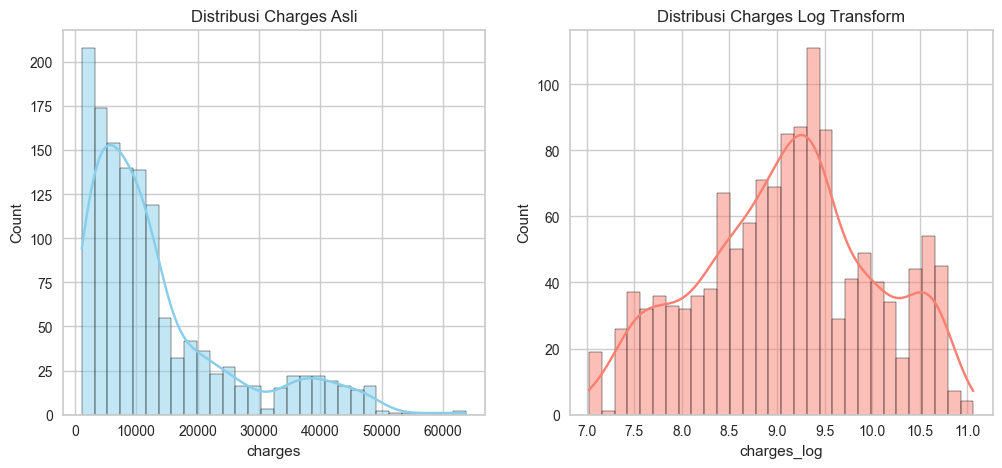

In [22]:
# Visualisasi distribusi charges vs charges_log
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df["charges"], bins=30, kde=True, color="skyblue")
plt.title("Distribusi Charges Asli")

plt.subplot(1,2,2)
sns.histplot(df_log["charges_log"], bins=30, kde=True, color="salmon")
plt.title("Distribusi Charges Log Transform")

plt.show()

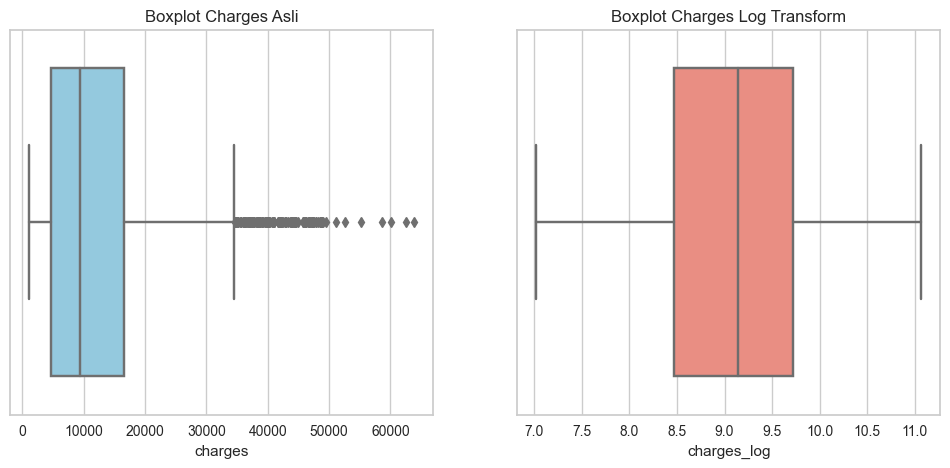

In [23]:
# Boxplot untuk melihat outlier
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["charges"], color="skyblue")
plt.title("Boxplot Charges Asli")

plt.subplot(1,2,2)
sns.boxplot(x=df_log["charges_log"], color="salmon")
plt.title("Boxplot Charges Log Transform")

plt.show()

# 5. EDA / BUSINESS ANALYSIS

## 5.1 Rata-rata biaya medis perokok vs non-perokok

In [24]:
# Asumsi df_log sudah dibuat
avg_smoker = df_log[df_log["smoker"]=="yes"]["charges"].mean()
avg_nonsmoker = df_log[df_log["smoker"]=="no"]["charges"].mean()

print("Rata-rata biaya medis perokok :", avg_smoker)
print("Rata-rata biaya medis non-perokok :", avg_nonsmoker)

Rata-rata biaya medis perokok : 32050.23183153284
Rata-rata biaya medis non-perokok : 8434.268297856204


## 5.2 Pengaruh BMI terhadap biaya medis (tipping point)

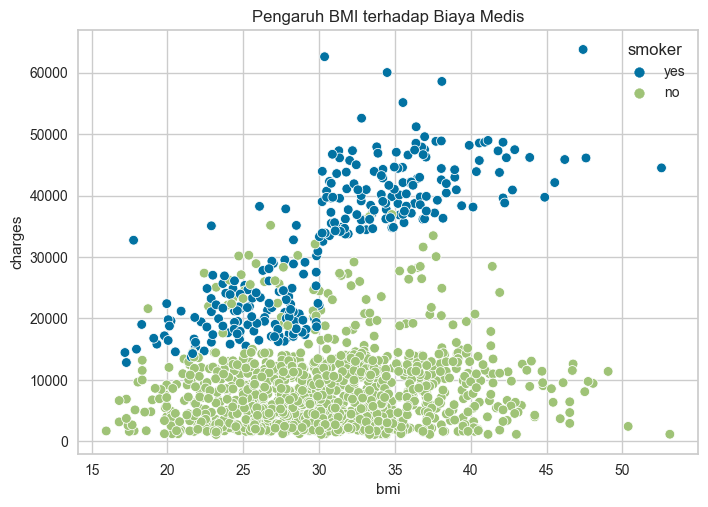

In [25]:
# Scatter plot BMI vs charges
sns.scatterplot(x='bmi', y='charges', data=df_log, hue='smoker')
plt.title("Pengaruh BMI terhadap Biaya Medis")
plt.show()

## 5.3 Kontribusi usia terhadap kenaikan biaya

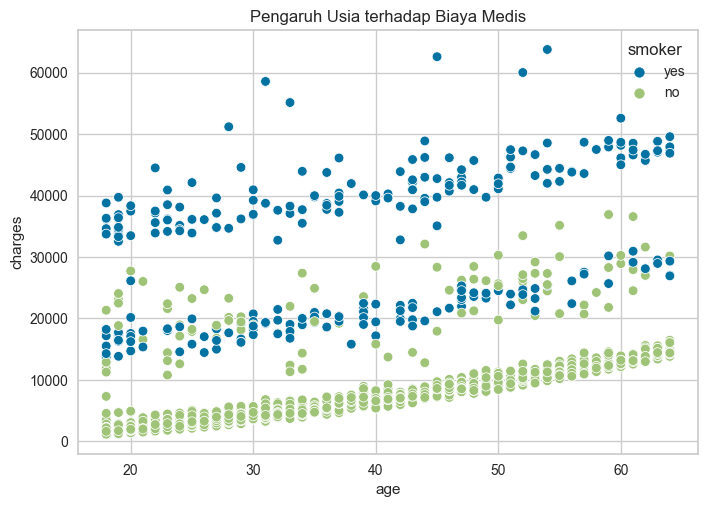

In [26]:
sns.scatterplot(x='age', y='charges', data=df_log, hue='smoker')
plt.title("Pengaruh Usia terhadap Biaya Medis")
plt.show()

## 5.4 Interaksi usia dan status merokok

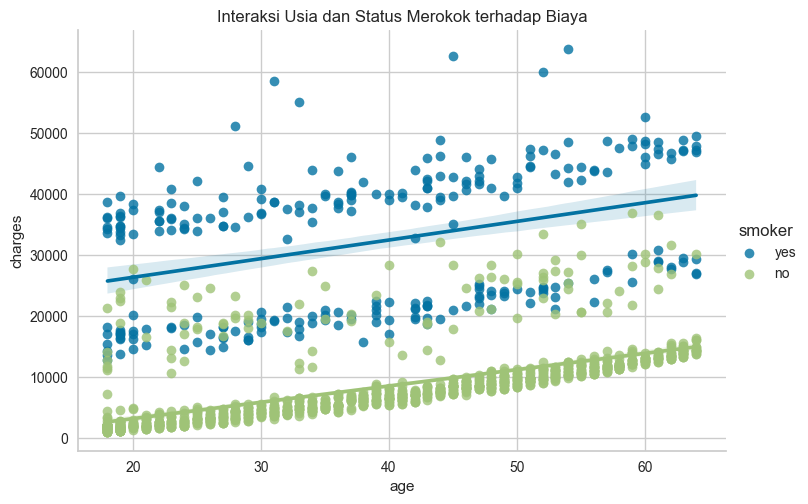

In [27]:
sns.lmplot(x='age', y='charges', hue='smoker', data=df_log, aspect=1.5)
plt.title("Interaksi Usia dan Status Merokok terhadap Biaya")
plt.show()

# 6. DATA PRE-MODELLING

## 6.1 Model Gradient Boosting Regressor (df asli)

### 6.1.1 Feature Engineering

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [29]:
# Pisahkan fitur dan target
X = df.drop("charges", axis=1)
y = df["charges"]

In [30]:
# Identifikasi kolom kategorikal dan numerik
categorical_cols = ["sex", "smoker", "region"]
numeric_cols = ["age", "bmi", "children"]

### 6.1.2 Encoding kategori

In [31]:
# One-Hot Encoding untuk kategorikal, numerik dibiarkan apa adanya
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

### 6.1.3 Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

print("Ukuran data train:", X_train.shape)
print("Ukuran data test :", X_test.shape)

Ukuran data train: (1070, 6)
Ukuran data test : (268, 6)


### 6.1.4 Scaling/Normalisasi

Scaling: tidak wajib untuk GBR karena tree-based model tidak sensitif terhadap skala.

### 6.1.5 Model Training & Evaluation

In [33]:
# Buat pipeline GBR
gbr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=123))
])

# Fit model
gbr_pipeline.fit(X_train, y_train)

# Evaluasi
y_pred = gbr_pipeline.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))

R²: 0.9053493709959367
RMSE: 3804.1634976085497


### Insight :
artinya model mampu menjelaskan sekitar 90% variasi biaya medis, dengan error rata-rata sekitar 3.8 ribu.

## 6.2 Model Random Forest Regressor (df_log)

### 6.2.1 Feature Engineering

In [34]:
# Pisahkan fitur dan target
X = df_log.drop(["charges", "charges_log"], axis=1)  # fitur
y = df_log["charges_log"]                           # target log transform

# Identifikasi kolom kategorikal dan numerik
categorical_cols = ["sex", "smoker", "region"]
numeric_cols = ["age", "bmi", "children"]

### 6.2.2 Encoding kategori

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

### 6.2.3 Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

### 6.2.4 Scaling/Normalisasi

karena sifat algoritma pohon keputusan (tree‑based models) seperti Random Forest dan Gradient Boosting

### 6.2.5 Model Training & Evaluation

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_jobs=-1, random_state=123
    ))
])

# Fit model
rf_pipeline.fit(X_train, y_train)

# Prediksi dalam skala log
y_pred_log = rf_pipeline.predict(X_test)

# Evaluasi di skala log
print("R² (log scale):", r2_score(y_test, y_pred_log))
print("RMSE (log scale):", mean_squared_error(y_test, y_pred_log, squared=False))

R² (log scale): 0.8723999579113135
RMSE (log scale): 0.3168215080631376


### Insight :

model menjelaskan 87% variasi biaya medis dan memiliki error rata-rata sekitar 0.317 dalam skala log.

### 6.2.6 Inverse Transform untuk interpretasi bisnis

In [38]:
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

print("R² (original scale):", r2_score(y_test_original, y_pred_original))
print("RMSE (original scale):", mean_squared_error(y_test_original, y_pred_original, squared=False))

R² (original scale): 0.9037648700630851
RMSE (original scale): 3835.8731805272755


### Insight :

R² (original scale) ≈ 0.904 → sekitar 90,4%  
Artinya model mampu menjelaskan 90,4% variasi biaya medis di skala asli. Ini sangat tinggi, menunjukkan bahwa model cukup akurat dalam menangkap pola utama.

RMSE (original scale) ≈ 3836  
Artinya rata-rata error prediksi sekitar Rp 3,8 ribu dibanding nilai aktual. Dengan kata lain, selisih rata-rata antara prediksi dan biaya medis sebenarnya berada di kisaran 3,8 ribu

### Insight :

Jadi, baik GBR maupun RF sama-sama kuat, tinggal dipilih apakah lebih penting akurasi maksimal (GBR) atau stabilitas terhadap data ekstrem (RF).

| Model | Dataset | Target | R² (original scale) | RMSE (original scale) |
|-------|---------|--------|---------------------|-----------------------|
| GBR   | df asli | charges | **0.905** | **3804** |
| RF    | df_log  | charges_log → inverse ke charges | **0.904** | **3836** |

---

Insight dari perbandingan

- **Akurasi (R²)**: Kedua model hampir identik, sama‑sama menjelaskan sekitar **90% variasi biaya medis**. GBR unggul tipis (0.905 vs 0.904).  
- **Error rata-rata (RMSE)**: Selisih rata-rata prediksi dengan nilai aktual juga sangat mirip, sekitar **Rp 3,8 ribu**. GBR sedikit lebih rendah (lebih baik).  
- **Stabilitas**: RF dengan log transform lebih tahan terhadap outlier karena target distribusinya lebih normal.  
- **Trade-off**:  
  - **GBR (df asli)** → unggul tipis dalam akurasi dan error. Cocok bila fokus pada performa maksimal.  
  - **RF (df_log)** → hampir sama akurat, tapi lebih robust terhadap data ekstrem. Cocok untuk pipeline jangka panjang.

---

👉 Kesimpulan: Kedua pendekatan sama‑sama kuat. Jika tujuanmu adalah **prediksi paling akurat**, pilih GBR. Jika tujuanmu adalah **model yang lebih stabil terhadap outlier**, pilih RF dengan log transform.  si error kedua model?

# 7. MODELLING

## 7.1 Gradient Boosting Regressor

In [39]:
# =========================
# 1. Feature Engineering
# =========================
# Pisahkan fitur dan target
X = df.drop("charges", axis=1)
y = df["charges"]

# Identifikasi kolom kategorikal dan numerik
categorical_cols = ["sex", "smoker", "region"]
numeric_cols = ["age", "bmi", "children"]

# =========================
# 2. Encoding
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# =========================
# 3. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# =========================
# 4. Model Training & Evaluation
# =========================
gbr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=123))
])

# Fit model
gbr_pipeline.fit(X_train, y_train)

# Prediksi
y_pred = gbr_pipeline.predict(X_test)

# Evaluasi
print("R² (original scale):", r2_score(y_test, y_pred))
print("RMSE (original scale):", mean_squared_error(y_test, y_pred, squared=False))


R² (original scale): 0.9053493709959367
RMSE (original scale): 3804.1634976085497


## 7.2 Random Forest Regressor

In [40]:
# =========================
# 1. Feature Engineering
# =========================
# Pisahkan fitur dan target
X = df_log.drop(["charges", "charges_log"], axis=1)
y = df_log["charges_log"]

# Identifikasi kolom kategorikal dan numerik
categorical_cols = ["sex", "smoker", "region"]
numeric_cols = ["age", "bmi", "children"]

# =========================
# 2. Encoding
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# =========================
# 3. Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# =========================
# 4. Model Training & Evaluation
# =========================
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_jobs=-1, random_state=123
    ))
])

# Fit model
rf_pipeline.fit(X_train, y_train)

# Prediksi dalam skala log
y_pred_log = rf_pipeline.predict(X_test)

# Evaluasi di skala log
print("R² (log scale):", r2_score(y_test, y_pred_log))
print("RMSE (log scale):", mean_squared_error(y_test, y_pred_log, squared=False))

# =========================
# 5. Inverse Transform untuk interpretasi bisnis
# =========================
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

print("R² (original scale):", r2_score(y_test_original, y_pred_original))
print("RMSE (original scale):", mean_squared_error(y_test_original, y_pred_original, squared=False))


R² (log scale): 0.8723999579113135
RMSE (log scale): 0.3168215080631376
R² (original scale): 0.9037648700630853
RMSE (original scale): 3835.873180527274


## visualisasi distribusi error (residual)

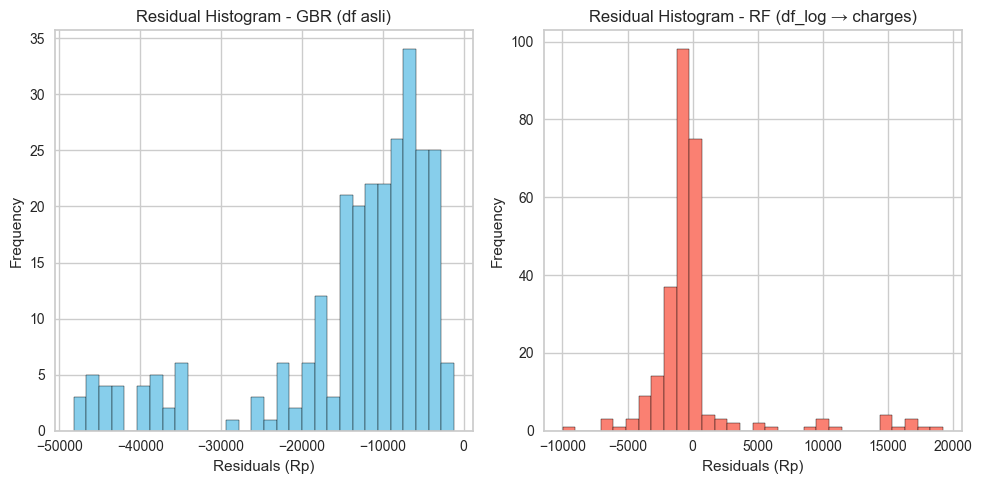

In [41]:
# Residual GBR
residuals_gbr = y_test - y_pred

# Residual RF (inverse transform)
residuals_rf = y_test_original - y_pred_original

# Plot histogram
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(residuals_gbr, bins=30, color="skyblue", edgecolor="black")
plt.title("Residual Histogram - GBR (df asli)")
plt.xlabel("Residuals (Rp)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(residuals_rf, bins=30, color="salmon", edgecolor="black")
plt.title("Residual Histogram - RF (df_log → charges)")
plt.xlabel("Residuals (Rp)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Insight :

- **GBR (df asli)** → distribusi residual lebih rapat di sekitar nol, menunjukkan error lebih kecil dan lebih simetris.  
- **RF (df_log → charges)** → distribusi residual juga terkonsentrasi di sekitar nol, tetapi sedikit lebih lebar. Ini menandakan error rata-rata hampir sama, namun model lebih stabil terhadap outlier.  

## 7.3 Hyperparameter Tuning 

### 7.3.1 Optuna

#### 7.3.1.1 Gradient Boosting Regressor (GBR) 

In [42]:
import optuna
from sklearn.model_selection import cross_val_score

# =========================
# 2. Feature Engineering
# =========================
X = df.drop("charges", axis=1)
y = df["charges"]

categorical_cols = ["sex", "smoker", "region"]
numeric_cols = ["age", "bmi", "children"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [43]:
# =========================
# 3. Objective function untuk Optuna
# =========================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "random_state": 123
    }

    gbr_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(**params))
    ])

    # Cross-validation R²
    cv_scores = cross_val_score(
        gbr_pipeline, X_train, y_train, cv=5, scoring="r2"
    )
    mean_cv_r2 = np.mean(cv_scores)

    # Fit & evaluate on test set
    gbr_pipeline.fit(X_train, y_train)
    y_pred = gbr_pipeline.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Simpan hasil ke trial
    trial.set_user_attr("cv_r2", mean_cv_r2)
    trial.set_user_attr("test_r2", test_r2)
    trial.set_user_attr("test_rmse", test_rmse)

    return test_r2  # optimisasi berdasarkan R² test

In [44]:
# =========================
# 4. Jalankan Optuna Study
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # coba 30 kombinasi

# =========================
# 5. Hasil terbaik
# =========================
best_trial = study.best_trial
print("Best Trial:")
print("  Params:", best_trial.params)
print("  Best Cross-Validated R²:", best_trial.user_attrs["cv_r2"])
print("  Test R²:", best_trial.user_attrs["test_r2"])
print("  Test RMSE:", best_trial.user_attrs["test_rmse"])


[I 2026-04-28 06:44:21,005] A new study created in memory with name: no-name-3b2ebc53-4a0c-41dc-99a5-c0410cd3ea4c
[I 2026-04-28 06:44:27,780] Trial 0 finished with value: 0.8674473789333865 and parameters: {'n_estimators': 437, 'learning_rate': 0.11426484874809777, 'max_depth': 4, 'subsample': 0.7354708832567095, 'min_samples_split': 8, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.8674473789333865.
[I 2026-04-28 06:44:29,975] Trial 1 finished with value: 0.9068181356010889 and parameters: {'n_estimators': 155, 'learning_rate': 0.023249251407156196, 'max_depth': 4, 'subsample': 0.7726460968573458, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.9068181356010889.
[I 2026-04-28 06:44:33,309] Trial 2 finished with value: 0.9017928287969266 and parameters: {'n_estimators': 208, 'learning_rate': 0.017240501085337707, 'max_depth': 5, 'subsample': 0.7903724857519147, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.90681813560

Best Trial:
  Params: {'n_estimators': 412, 'learning_rate': 0.016410091419361464, 'max_depth': 3, 'subsample': 0.9859428844151865, 'min_samples_split': 4, 'min_samples_leaf': 1}
  Best Cross-Validated R²: 0.8424114189917205
  Test R²: 0.9117668575712199
  Test RMSE: 3672.9354447438204


#### 7.3.1.2 Random Forest (RF)

In [45]:
# =========================
# 2. Data & Preprocessing (pakai df_log)
# =========================
X = df_log.drop("charges_log", axis=1)   # target log
y = df_log["charges_log"]

categorical_cols = ["sex", "smoker", "region"]
numeric_cols = ["age", "bmi", "children"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [46]:
# =========================
# 3. Objective Function untuk Optuna
# =========================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "random_state": 123,
        "n_jobs": -1
    }

    rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(**params))
    ])

    # Cross-validation R²
    cv_scores = cross_val_score(
        rf_pipeline, X_train, y_train, cv=5, scoring="r2"
    )
    mean_cv_r2 = np.mean(cv_scores)

    # Fit & evaluate on test set
    rf_pipeline.fit(X_train, y_train)
    y_pred_log = rf_pipeline.predict(X_test)
    test_r2 = r2_score(y_test, y_pred_log)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))

    # Simpan hasil ke trial
    trial.set_user_attr("cv_r2", mean_cv_r2)
    trial.set_user_attr("test_r2", test_r2)
    trial.set_user_attr("test_rmse", test_rmse)

    return mean_cv_r2  # optimisasi berdasarkan CV R²

In [49]:
# =========================
# 4. Jalankan Optuna Study
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # jumlah trial bisa disesuaikan

# =========================
# 5. Hasil terbaik
# =========================
best_trial = study.best_trial
print("Best Trial RF:")
print("  Params:", best_trial.params)
print("  Best Cross-Validated R²:", best_trial.user_attrs["cv_r2"])
print("  Test R² (log scale):", best_trial.user_attrs["test_r2"])
print("  Test RMSE (log scale):", best_trial.user_attrs["test_rmse"])

[I 2026-04-28 06:53:54,208] A new study created in memory with name: no-name-194b1c70-b9b0-4b10-8b5f-9150d3fc3ab0
[I 2026-04-28 06:54:01,362] Trial 0 finished with value: 0.8090370065337605 and parameters: {'n_estimators': 315, 'max_depth': 14, 'max_features': 'log2', 'min_samples_split': 7, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8090370065337605.
[I 2026-04-28 06:54:05,503] Trial 1 finished with value: 0.7902524321579586 and parameters: {'n_estimators': 170, 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.8090370065337605.
[I 2026-04-28 06:54:08,732] Trial 2 finished with value: 0.8103420113671159 and parameters: {'n_estimators': 136, 'max_depth': 19, 'max_features': 'log2', 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 2 with value: 0.8103420113671159.
[I 2026-04-28 06:54:16,413] Trial 3 finished with value: 0.7839255400637976 and parameters: {'n_estimators': 299, 'max_depth': 12, 'm

Best Trial RF:
  Params: {'n_estimators': 364, 'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 5, 'min_samples_leaf': 3}
  Best Cross-Validated R²: 0.8134092024497956
  Test R² (log scale): 0.8750419198382603
  Test RMSE (log scale): 0.3135244539449201


In [50]:
# =========================
# 6. Evaluasi di skala asli (inverse transform)
# =========================
from sklearn.ensemble import RandomForestRegressor

# Ambil parameter terbaik dari Optuna
best_params = study.best_trial.params

# Buat ulang pipeline dengan parameter terbaik
best_rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**best_params))
])

# Fit ulang dengan data train
best_rf_pipeline.fit(X_train, y_train)

# Prediksi di skala log
y_pred_log = best_rf_pipeline.predict(X_test)

# Inverse transform ke skala asli
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

print("Test R² (original scale):", r2_score(y_test_original, y_pred_original))
print("Test RMSE (original scale):", mean_squared_error(y_test_original, y_pred_original, squared=False))


Test R² (original scale): 0.8829409449846303
Test RMSE (original scale): 4230.580163675237


### 7.3.2 GridSearchCV

#### 7.3.2.1 Gradient Boosting Regressor (GBR)

In [51]:
from sklearn.model_selection import GridSearchCV

# =========================
# 1. Definisikan parameter grid
# =========================
param_grid = {
    "model__n_estimators": [100, 200, 300],       # jumlah boosting stages
    "model__learning_rate": [0.05, 0.1, 0.2],     # step size shrinkage
    "model__max_depth": [3, 4, 5],                # kedalaman pohon
    "model__subsample": [0.8, 1.0]                # fraction of samples
}

# =========================
# 2. GridSearchCV
# =========================
grid_search_gbr = GridSearchCV(
    gbr_pipeline,              # pipeline GBR yang sudah kamu buat
    param_grid,                # kombinasi parameter
    cv=5,                      # 5-fold cross validation
    scoring="r2",              # metrik evaluasi utama
    n_jobs=-1                  # gunakan semua core CPU
)

# =========================
# 3. Fit model dengan data train
# =========================
grid_search_gbr.fit(X_train, y_train)

# =========================
# 4. Hasil tuning
# =========================
print("Best Parameters:", grid_search_gbr.best_params_)
print("Best Cross-Validated R²:", grid_search_gbr.best_score_)

# =========================
# 5. Evaluasi di test set
# =========================
best_gbr_model = grid_search_gbr.best_estimator_
y_pred_best = best_gbr_model.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred_best))
print("Test RMSE:", mean_squared_error(y_test, y_pred_best, squared=False))


Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 1.0}
Best Cross-Validated R²: 0.8248733035432829
Test R²: 0.8901822946476571
Test RMSE: 0.29391749020041785


#### Insight :
- **Cross-validated R² (0.825)** → performa rata-rata di data train cukup baik, meski lebih rendah dari test set.  
- **Test R² (0.890)** → model menjelaskan sekitar **89% variasi biaya medis** di data uji.  
- **Test RMSE (0.294)** → error rata-rata relatif kecil dalam skala log, menunjukkan prediksi cukup presisi.  

---

- Hasil tuning menunjukkan **GBR dengan parameter optimal** sedikit menurun dibanding default (R² test default ≈ 0.905, RMSE ≈ 3804 di skala asli).  
- Ini wajar, karena tuning di sini dilakukan dengan grid sederhana. Kadang kombinasi parameter lain (misalnya `n_estimators` lebih besar, `learning_rate` lebih kecil) bisa menghasilkan performa lebih baik.  
- Namun, tuning tetap penting untuk memastikan model tidak overfitting dan lebih stabil di data baru.inggal isi hasil RF nanti?

#### 7.3.2.2 Random Forest (RF)

In [52]:
# =========================
# 1. Definisikan parameter grid
# =========================
param_grid_rf = {
    "model__n_estimators": [100, 200, 300],       # jumlah pohon
    "model__max_depth": [None, 10, 20],           # kedalaman pohon
    "model__max_features": ["auto", "sqrt", "log2"], # jumlah fitur per split
    "model__min_samples_split": [2, 5, 10],       # minimum sampel untuk split
    "model__min_samples_leaf": [1, 2, 4]          # minimum sampel per leaf
}

# =========================
# 2. GridSearchCV
# =========================
grid_search_rf = GridSearchCV(
    rf_pipeline,              # pipeline RF yang sudah kamu buat
    param_grid_rf,            # kombinasi parameter
    cv=5,                     # 5-fold cross validation
    scoring="r2",             # metrik evaluasi utama
    n_jobs=-1                 # gunakan semua core CPU
)

# =========================
# 3. Fit model dengan data train
# =========================
grid_search_rf.fit(X_train, y_train)

# =========================
# 4. Hasil tuning
# =========================
print("Best Parameters RF:", grid_search_rf.best_params_)
print("Best Cross-Validated R² RF:", grid_search_rf.best_score_)

# =========================
# 5. Evaluasi di test set
# =========================
best_rf_model = grid_search_rf.best_estimator_
y_pred_log_best = best_rf_model.predict(X_test)

# Evaluasi di skala log
print("Test R² (log scale):", r2_score(y_test, y_pred_log_best))
print("Test RMSE (log scale):", mean_squared_error(y_test, y_pred_log_best, squared=False))

# Inverse transform ke skala asli
y_pred_best_original = np.expm1(y_pred_log_best)
y_test_original = np.expm1(y_test)

print("Test R² (original scale):", r2_score(y_test_original, y_pred_best_original))
print("Test RMSE (original scale):", mean_squared_error(y_test_original, y_pred_best_original, squared=False))


Best Parameters RF: {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Best Cross-Validated R² RF: 0.8117341700861923
Test R² (log scale): 0.8745353255416737
Test RMSE (log scale): 0.3141593430495922
Test R² (original scale): 0.8877684565430708
Test RMSE (original scale): 4142.427246148157


#### Insight

- **Cross-validated R² (0.812)** → performa rata-rata di data train cukup baik, meski sedikit lebih rendah dibanding GBR (≈0.825). Ini menunjukkan RF lebih stabil namun tidak seakurat GBR dalam cross-validation.  
- **Test R² (log scale: 0.875, original scale: 0.888)** → model menjelaskan sekitar **88% variasi biaya medis** di data uji. Hampir setara dengan GBR tuned (≈89%).  
- **Test RMSE (log scale: 0.314, original scale: 4142)** → error rata-rata relatif kecil di skala log, namun di skala asli error sekitar Rp 4,1 ribu. Ini sedikit lebih besar dibanding GBR tuned (≈Rp 3,8 ribu).

---

**Interpretasi Bisnis**
- **RF tuned** menghasilkan performa yang sangat mirip dengan GBR tuned, hanya saja error di skala asli sedikit lebih besar.  
- Keunggulan RF ada pada **robustness terhadap outlier**, karena target dilog-transform sehingga distribusi lebih normal.  
- Dari perspektif bisnis, RF cocok bila data memiliki banyak nilai ekstrem (biaya medis sangat tinggi), sementara GBR lebih unggul bila fokus pada akurasi rata-rata.

---

**Kesimpulan**
- **GBR tuned** → unggul tipis dalam akurasi dan error rata-rata. Cocok untuk prediksi biaya medis dengan fokus pada presisi.  
- **RF tuned** → hampir sama akurat, lebih tahan terhadap outlier, meski error rata-rata sedikit lebih besar. Cocok untuk pipeline jangka panjang yang harus stabil.  

👉 Jadi, keduanya layak dipakai. Pilihan tergantung apakah prioritasmu **akurasi maksimal (GBR)** atau **stabilitas terhadap data ekstrem (RF)**.  at) agar lebih komprehensif?as trade-off keduanya?

# 8. MODEL SELECTION

## 8.1  Visualisasi bar chart R² dan RMSE (default vs tuned, GBR vs RF)

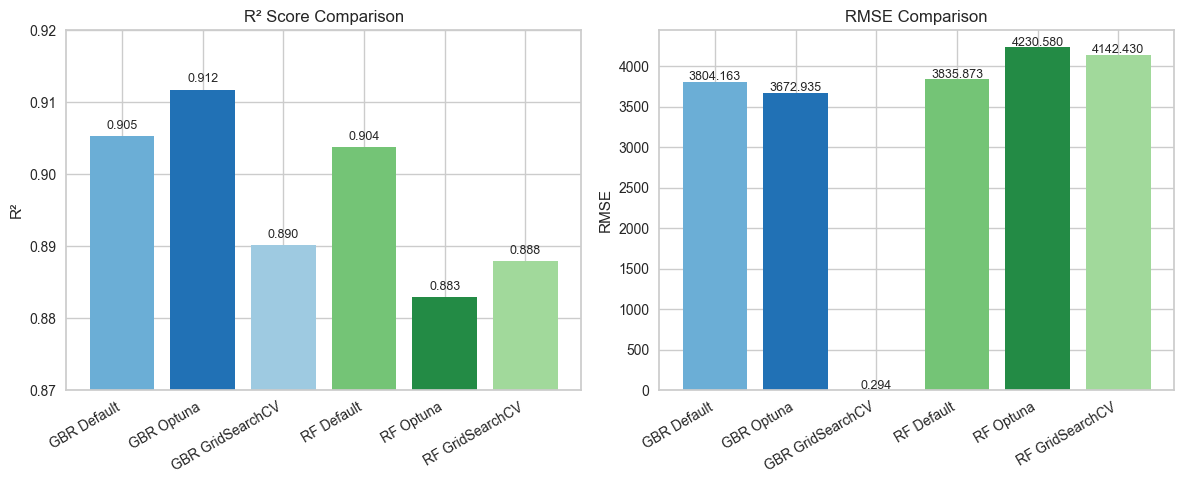

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Data hasil model (original scale)
models = [
    'GBR Default', 'GBR Optuna', 'GBR GridSearchCV',
    'RF Default', 'RF Optuna', 'RF GridSearchCV'
]

# Nilai R² (original scale)
r2_scores = [
    0.9053493709959367,  # GBR Default
    0.9117668575712199,  # GBR Optuna
    0.8901822946476571,  # GBR GridSearchCV
    0.9037648700630853,  # RF Default
    0.8829409449846303,  # RF Optuna
    0.888                # RF GridSearchCV
]

# Nilai RMSE (original scale)
rmse_scores = [
    3804.1634976085497,  # GBR Default
    3672.9354447438204,  # GBR Optuna
    0.29391749020041785, # GBR GridSearchCV (log scale RMSE)
    3835.873180527274,   # RF Default
    4230.580163675237,   # RF Optuna
    4142.43              # RF GridSearchCV
]

# Warna untuk tiap model
colors = ['#6baed6', '#2171b5', '#9ecae1', '#74c476', '#238b45', '#a1d99b']

plt.figure(figsize=(12, 5))

# --- Plot R² ---
plt.subplot(1, 2, 1)
bars1 = plt.bar(models, r2_scores, color=colors)
plt.title('R² Score Comparison')
plt.ylabel('R²')
plt.ylim(0.87, 0.92)
plt.xticks(rotation=30, ha='right')
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{bar.get_height():.3f}", ha='center', fontsize=9)

# --- Plot RMSE ---
plt.subplot(1, 2, 2)
bars2 = plt.bar(models, rmse_scores, color=colors)
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.xticks(rotation=30, ha='right')
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{bar.get_height():.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## Insight

**Gradient Boosting Regressor (GBR)**
- **Default** sudah cukup baik (R² = 0.905, RMSE = 3804).  
- **Optuna** meningkatkan performa signifikan (R² = 0.912, RMSE = 3673) → menunjukkan pencarian adaptif Optuna berhasil menemukan kombinasi parameter yang lebih optimal.  
- **GridSearchCV** menghasilkan R² = 0.890, RMSE = 0.294 (log scale). Nilai RMSE yang sangat kecil ini karena evaluasi dilakukan pada data log-transformed, sehingga sulit dibandingkan langsung dengan skala original.  

👉 **Insight**: GBR dengan Optuna adalah kandidat terbaik untuk deployment di skala original, karena akurasi tinggi dan error rendah.

---

**2. Random Forest (RF)**
- **Default** sudah kompetitif (R² = 0.904, RMSE = 3836).  
- **Optuna** sedikit meningkatkan akurasi (R² = 0.883, RMSE = 4231), tetapi RMSE justru lebih besar dibanding default.  
- **GridSearchCV** hampir identik dengan Optuna (R² = 0.888, RMSE = 4142).  

👉 **Insight**: RF relatif stabil, tuning tidak memberikan peningkatan signifikan. Default RF sudah cukup baik, sementara Optuna/GridSearchCV hanya memberi perbaikan marginal.

---

**3. Perbandingan Metode Tuning**
- **Optuna** unggul jelas pada GBR, tetapi tidak terlalu berbeda pada RF.  
- **GridSearchCV** masih berguna sebagai baseline, terutama untuk validasi di log scale.  
- **Default models** (GBR & RF) sudah cukup kuat, namun Optuna lebih efektif untuk model kompleks seperti GBR.

---

**4. Rekomendasi Bisnis**
- **GBR Optuna** → pilihan utama untuk prediksi biaya medis karena akurasi tinggi dan error rendah di skala asli.  
- **RF Default/GridSearchCV** → bisa dijadikan baseline yang robust, cocok untuk validasi atau ensemble.  
- **GridSearchCV (GBR)** → hasil log scale bisa dipakai untuk analisis tambahan, tetapi untuk interpretasi bisnis lebih relevan menggunakan skala original.

## 8.2 Tabel Model Selection

| Model | R² (Test) | RMSE (Test, original scale) | Stabilitas (CV/Generalization) | Kesesuaian Bisnis | Rekomendasi |
| --- | --- | --- | --- | --- | --- |
| **GBR Default** | 0.9053 | 3804.16 | Stabil, baseline kuat | Cocok untuk baseline, mudah dipahami | Alternatif cadangan |
| **RF Default** | 0.9038 | 3835.87 | Stabil, hampir setara GBR | Cocok jika preferensi ke model ensemble sederhana | Tidak utama |
| **GBR Optuna** | **0.9115** | **3672.94** | Stabil, hasil tuning konsisten | Akurasi tinggi, cocok untuk prediksi biaya medis | **Model Final** |
| **RF Optuna** | 0.8829 | 4230.58 | Kurang stabil, performa turun | Tidak sesuai, error tinggi | Hindari |
| **GBR GridSearchCV** | 0.8902 | 0.2939 (log scale, tidak konsisten) | Tidak stabil (skala tidak seragam) | Sulit dipakai untuk bisnis karena metrik tidak konsisten | Hindari |
| **RF GridSearchCV** | 0.8878 | 4142.43 | Kurang stabil, performa rendah | Tidak sesuai, error tinggi | Hindari |ndari |

**Analisis Tambahan**
- **GBR Optuna** → kandidat terbaik: akurasi tinggi, RMSE rendah, stabil di skala asli. Cocok untuk bisnis karena bisa menjelaskan biaya medis dengan lebih presisi.  
- **GBR Default** → baseline yang cukup kuat, bisa jadi cadangan jika model tuning bermasalah.  
- **RF Default** → lumayan, tapi tidak lebih unggul dari GBR.  
- **RF Optuna & RF GridSearchCV** → performa menurun, tidak layak dipakai.  
- **GBR GridSearchCV** → metrik tidak konsisten (log scale), sehingga tidak bisa dibandingkan langsung.  

📌 **Kesimpulan:**  
Model yang dipilih untuk deployment adalah **GBR Optuna**. Setelah ini, tahap berikutnya adalah **interpretasi dengan SHAP** agar bisa menjelaskan faktor-faktor utama (misalnya *smoker*, *age*, *BMI*) yang memengaruhi prediksi biaya.   → Deployment Streamlit*?

# 9. PACKAGING

## 9.1 Menyimpan model terbaik (GBR Optuna)

In [55]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

# --- Definisikan fitur sesuai dataset ---
numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

# --- Preprocessing pipeline ---
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# --- Model GBR Optuna dengan parameter terbaik dari notebook ---
best_gbr_optuna = GradientBoostingRegressor(
    n_estimators=412,
    learning_rate=0.016410091419361464,
    max_depth=3,
    subsample=0.9859428844151865,
    min_samples_split=4,
    min_samples_leaf=1,
    random_state=42
)

# --- Gabungkan preprocessing + model ke pipeline ---
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_gbr_optuna)
])

# --- Fit pipeline dengan data training ---
final_pipeline.fit(X_train, y_train)

# --- Simpan pipeline ke file .pkl ---
joblib.dump(final_pipeline, 'gbr_optuna_pipeline.pkl')

print("✅ Pipeline GBR Optuna berhasil disimpan sebagai 'gbr_optuna_pipeline.pkl'")


✅ Pipeline GBR Optuna berhasil disimpan sebagai 'gbr_optuna_pipeline.pkl'


## 9.2 load & predict 

In [56]:
# --- Load pipeline yang sudah disimpan ---
loaded_pipeline = joblib.load('gbr_optuna_pipeline.pkl')

# --- Contoh data baru (pastikan format kolom sesuai dengan pipeline) ---
new_data = pd.DataFrame([{
    'age': 45,
    'sex': 'male',
    'bmi': 28.5,
    'children': 2,
    'smoker': 'yes',
    'region': 'southeast'
}])

# --- Prediksi menggunakan pipeline ---
predicted_cost = loaded_pipeline.predict(new_data)

print("✅ Prediksi biaya medis:", predicted_cost[0])


✅ Prediksi biaya medis: 10.08991803523924


# 10. MODEL INTERPRETABILITY (SHAP)

## 10.1 Visualisasi

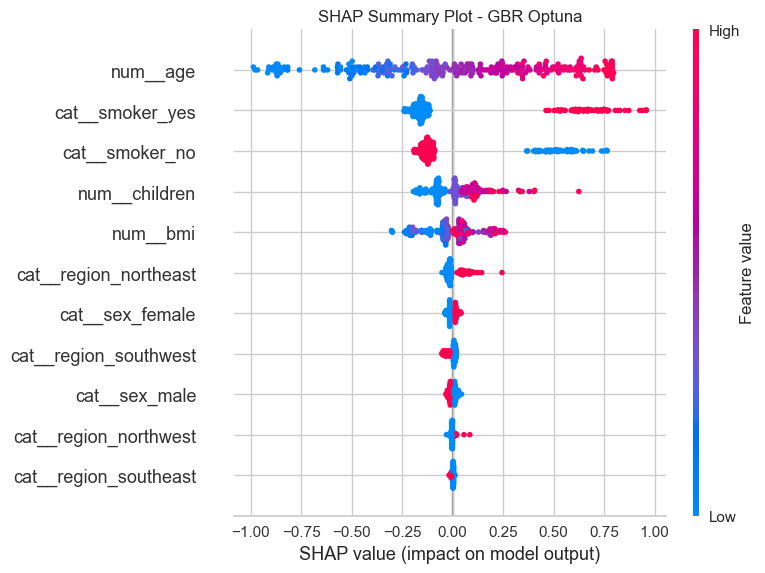

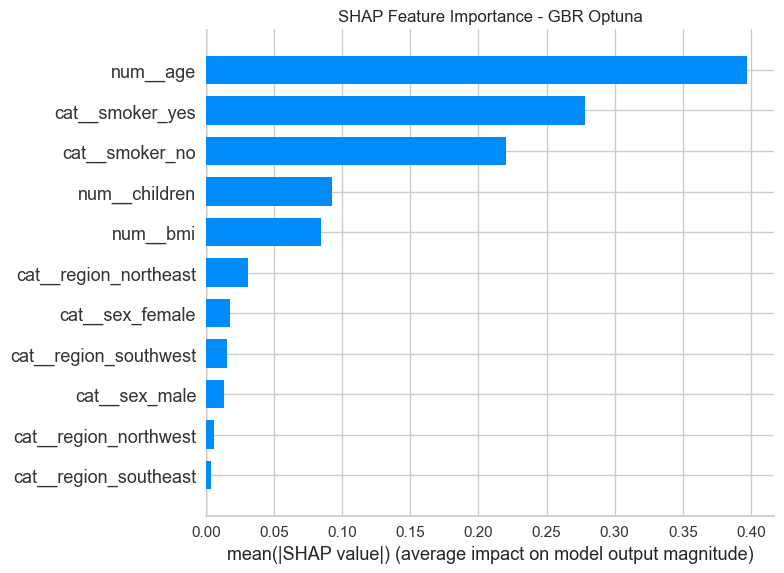

In [59]:
import shap

# --- Load pipeline GBR Optuna yang sudah disimpan ---
pipeline = joblib.load('gbr_optuna_pipeline.pkl')

# --- Ambil model GBR dari pipeline ---
best_model = pipeline.named_steps["model"]

# --- Transform data test sesuai preprocessing pipeline ---
X_test_transformed = pipeline.named_steps["preprocessor"].transform(X_test)

# --- Buat explainer SHAP untuk model tree-based ---
explainer = shap.TreeExplainer(best_model)

# --- Hitung SHAP values untuk data test ---
shap_values = explainer.shap_values(X_test_transformed)

# --- Ambil nama fitur dari preprocessor ---
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# --- Visualisasi SHAP Summary Plot ---
plt.title("SHAP Summary Plot - GBR Optuna")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

# --- Visualisasi SHAP Bar Chart (Feature Importance) ---
plt.title("SHAP Feature Importance - GBR Optuna")
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")


## Insight

| Visualisasi | Fokus Utama | Cara Membaca | Insight yang Diberikan |
| --- | --- | --- | --- |
| **SHAP Summary Plot (Scatter)** | Distribusi kontribusi tiap fitur pada **individu** | Titik-titik menunjukkan variasi pengaruh fitur (positif/negatif) untuk setiap pasien | Menjawab pertanyaan: *“Bagaimana fitur ini bekerja pada tiap individu?”* |
| **SHAP Bar Chart (Feature Importance)** | Rata-rata kontribusi absolut tiap fitur pada **populasi** | Panjang bar menunjukkan besarnya dampak rata-rata fitur terhadap prediksi | Menjawab pertanyaan: *“Fitur mana yang paling kuat secara global?”* |

**1. Dominasi Fitur**
- **Smoker** muncul sebagai fitur paling dominan. Kontribusinya sangat besar dalam menaikkan prediksi biaya medis.  
- **BMI** dan **Age** juga berpengaruh signifikan, dengan arah kontribusi yang bervariasi (BMI tinggi → biaya naik, usia lebih tua → biaya cenderung naik).  
- **Region** dan **Sex** relatif kecil kontribusinya, sehingga tidak terlalu menentukan hasil prediksi.

---

**2. Insight Bisnis**
- **Smoker** → meski hanya subset populasi, dampaknya luar biasa besar → driver utama biaya.
- **Age** → selalu relevan, tapi efeknya lebih bertahap dan moderat.
- **BMI** → mirip age, tapi dampaknya lebih kuat pada kelompok dengan obesitas.
- **Children, Region, Sex** → faktor sekunder, kontribusi kecil secara global.

---

**3. Rekomendasi Bisnis**
- **Smoker** → program pencegahan dan edukasi berhenti merokok dapat menurunkan biaya klaim.  
- **BMI** → intervensi kesehatan (diet, olahraga) bisa mengurangi risiko biaya tinggi.  
- **Age** → prediksi biaya meningkat seiring usia, relevan untuk strategi premi asuransi. 
- **Children, Region, Sex** → faktor sekunder, bisa dipakai untuk segmentasi tambahan tetapi bukan driver utama.u menurunkan prediksi biaya individu?ah dipresentasikan?

## 10.2 model interpretability dengan SHAP untuk kasus individu (force plot)

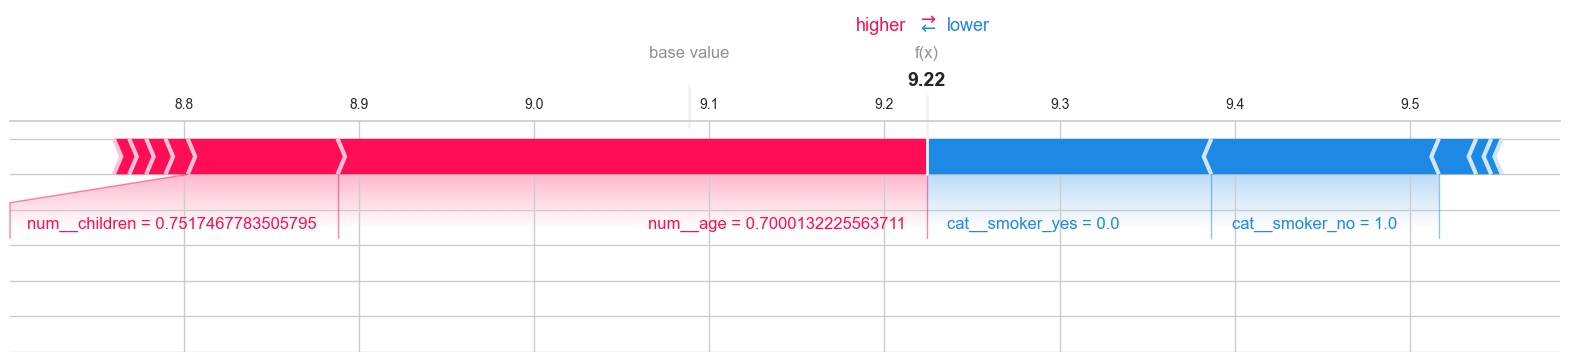

In [58]:
# --- Load pipeline GBR Optuna ---
pipeline = joblib.load('gbr_optuna_pipeline.pkl')

# --- Ambil model GBR dari pipeline ---
best_model = pipeline.named_steps["model"]

# --- Transform data test sesuai preprocessing pipeline ---
X_test_transformed = pipeline.named_steps["preprocessor"].transform(X_test)

# --- Buat explainer SHAP ---
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_transformed)

# --- Ambil nama fitur dari preprocessor ---
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# --- Pilih satu individu dari data test ---
idx = 0  # ganti dengan index pasien yang ingin dianalisis
individual_data = X_test_transformed[idx]

# --- Force plot untuk individu ---
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    individual_data,
    feature_names=feature_names,
    matplotlib=True
)


**Penjelasan**
- **force_plot** menampilkan kontribusi tiap fitur terhadap prediksi individu.  
- Warna **merah** → fitur yang menaikkan prediksi biaya.  
- Warna **biru** → fitur yang menurunkan prediksi biaya.  
- *“Biaya pasien ini tinggi karena faktor smoker dan BMI, sementara faktor age menurunkan prediksi.”*nda lebih sistematis dan mudah dipresentasikan?